<a href="https://colab.research.google.com/github/Sadikunnahar534/Admin_Pharma_Track/blob/main/Sadikunnahar_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import time

In [3]:
from google.colab import files
uploaded = files.upload()

Saving NF-ToN-IoT-v2.csv to NF-ToN-IoT-v2.csv


In [4]:
df = pd.read_csv('NF-ToN-IoT-v2.csv')
print(df.shape)

(3000001, 44)


In [5]:
df = df.drop(columns=['IPV4_SRC_ADDR', 'IPV4_DST_ADDR'])

X = df.drop(columns=['Label'])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:81: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2


(2400000, 41) (600001, 41)


Random Forest

In [9]:
print(X_train.isnull().sum().sum())
print(np.isinf(X_train.values).sum())

0
0


In [11]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("Train inf:", np.isinf(X_train.values).sum())
print("Test inf:", np.isinf(X_test.values).sum())
print("Train nan:", X_train.isnull().sum().sum())
print("Test nan:", X_test.isnull().sum().sum())

Train inf: 0
Test inf: 0
Train nan: 0
Test nan: 0


In [13]:
for col in X_train.columns:
    cap = X_train[col].quantile(0.999)
    X_train[col] = X_train[col].clip(upper=cap)
    X_test[col] = X_test[col].clip(upper=cap)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

print("Train finite:", np.isfinite(X_train.values).all())
print("Test finite:", np.isfinite(X_test.values).all())

Train finite: True
Test finite: True


XGBoost training

In [14]:
start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    tree_method='hist', n_jobs=-1, random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))

print(f"XGB time: {time.time()-start:.1f} sec")

XGB Accuracy: 0.9949750083749861
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    216032
           1       0.99      1.00      1.00    383969

    accuracy                           0.99    600001
   macro avg       1.00      0.99      0.99    600001
weighted avg       0.99      0.99      0.99    600001

[[213895   2137]
 [   878 383091]]
XGB time: 101.8 sec


In [15]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

LONGEST_FLOW_PKT              0.251119
SRC_TO_DST_SECOND_BYTES       0.216345
MAX_TTL                       0.100669
DNS_TTL_ANSWER                0.093308
L7_PROTO                      0.047919
L4_SRC_PORT                   0.039740
TCP_FLAGS                     0.038365
SHORTEST_FLOW_PKT             0.032782
CLIENT_TCP_FLAGS              0.026431
TCP_WIN_MAX_IN                0.023746
MIN_IP_PKT_LEN                0.020340
FLOW_DURATION_MILLISECONDS    0.015867
L4_DST_PORT                   0.011679
OUT_BYTES                     0.009710
DNS_QUERY_TYPE                0.009678
dtype: float32


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

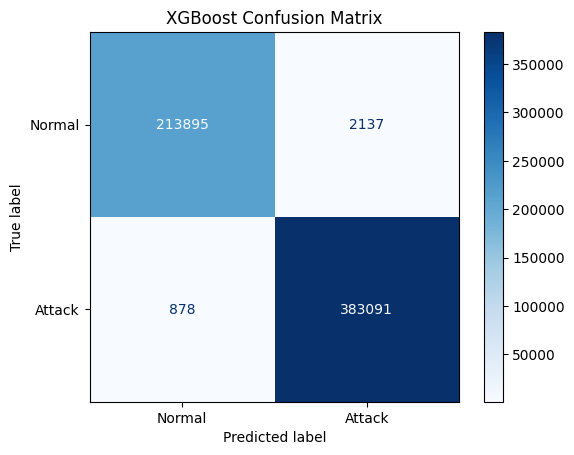

In [17]:
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

Bar chart


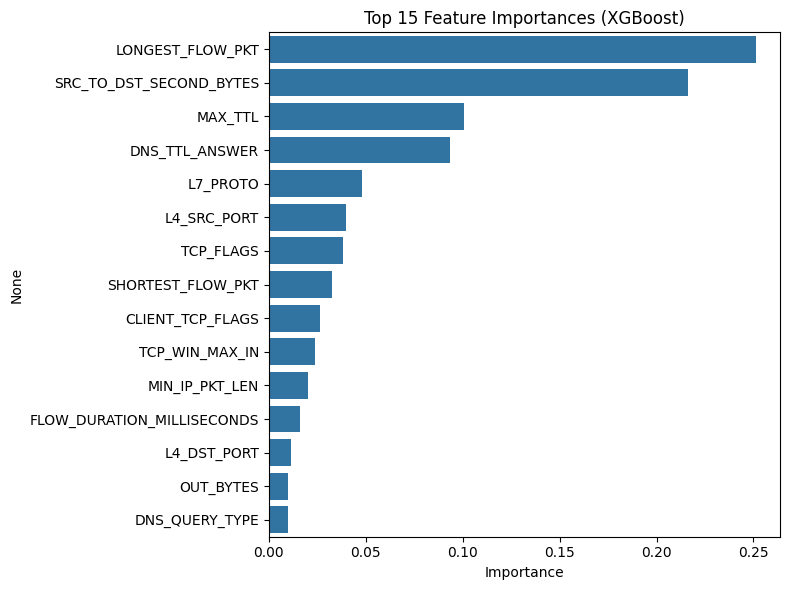

In [18]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

ROC Curve

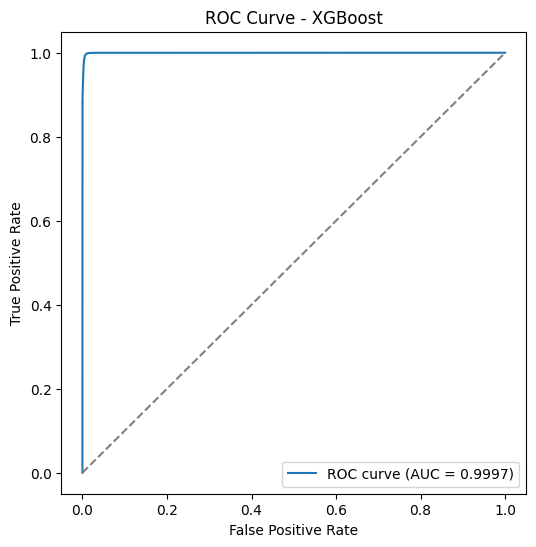

In [19]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

Class distribution

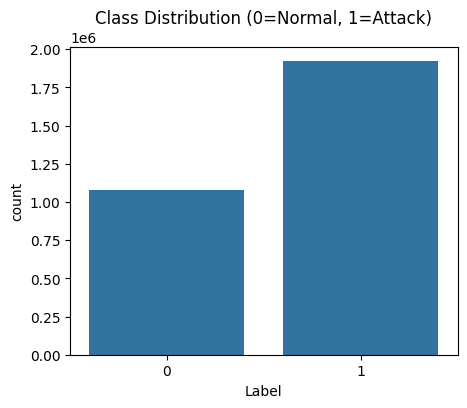

In [20]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title('Class Distribution (0=Normal, 1=Attack)')
plt.show()

Logistic regression

In [21]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2400000, 41) Test shape: (600001, 41)


Scaling

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression training

In [24]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
start = time.time()

lr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

print(f"LR time: {time.time()-start:.1f} sec")

LR Accuracy: 0.8194169676383872
              precision    recall  f1-score   support

           0       0.72      0.82      0.77    216032
           1       0.89      0.82      0.85    383969

    accuracy                           0.82    600001
   macro avg       0.80      0.82      0.81    600001
weighted avg       0.83      0.82      0.82    600001

[[177299  38733]
 [ 69617 314352]]
LR time: 50.2 sec


Confusion Matrix

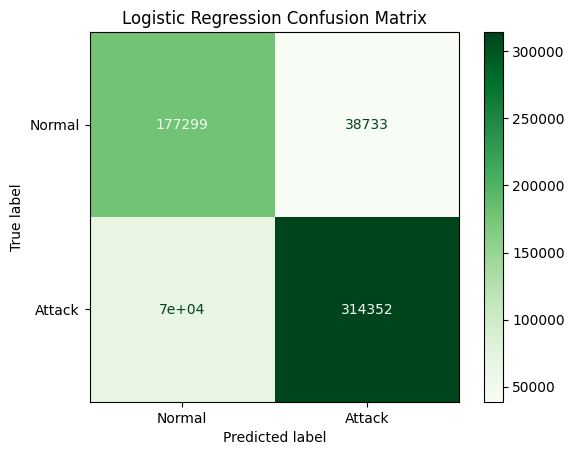

In [26]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

ROC Curve

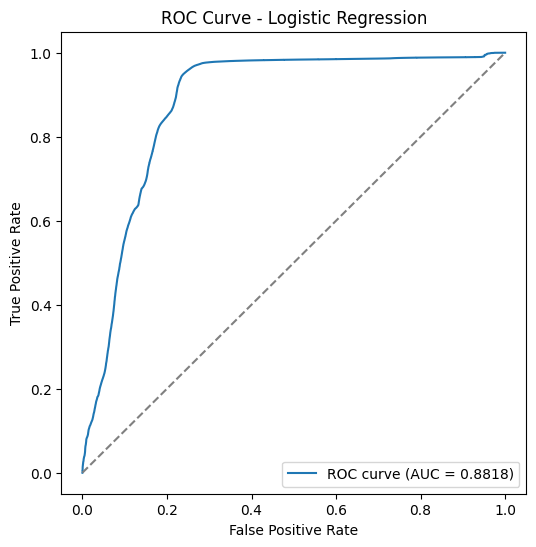

In [27]:
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

Feature Coefficients

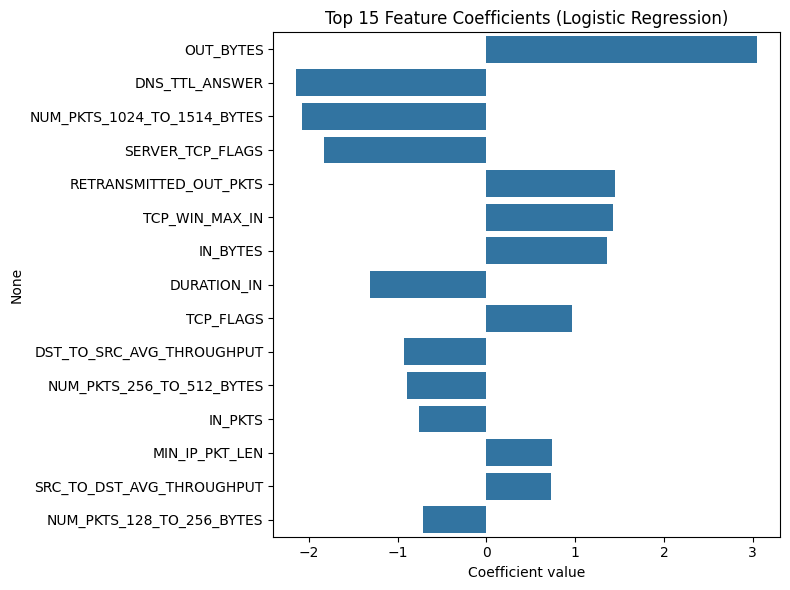

In [28]:
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=coef.head(15).values, y=coef.head(15).index)
plt.title('Top 15 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

Precision-Recall

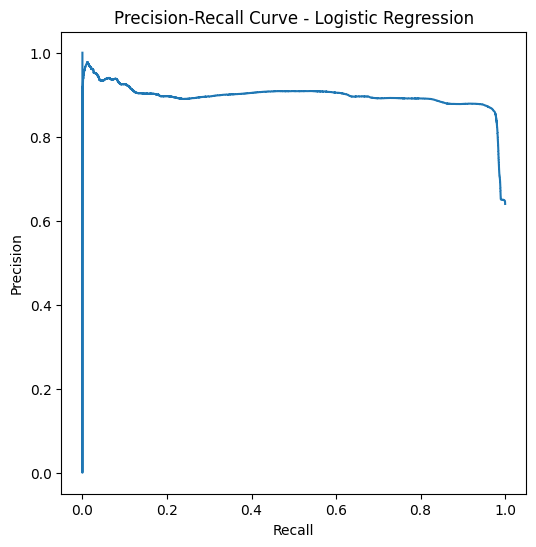

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, lr_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()